<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week4_Actvidad_4./blob/main/S4_Actividad_4_Regularizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tamaño de entrenamiento: 640 muestras
Tamaño de validación: 160 muestras
Tamaño de prueba: 200 muestras
Entrenando Modelo Base...
Entrenamiento del Modelo Base finalizado.
Entrenando Modelo Regularizado...
Entrenamiento del Modelo Regularizado finalizado.


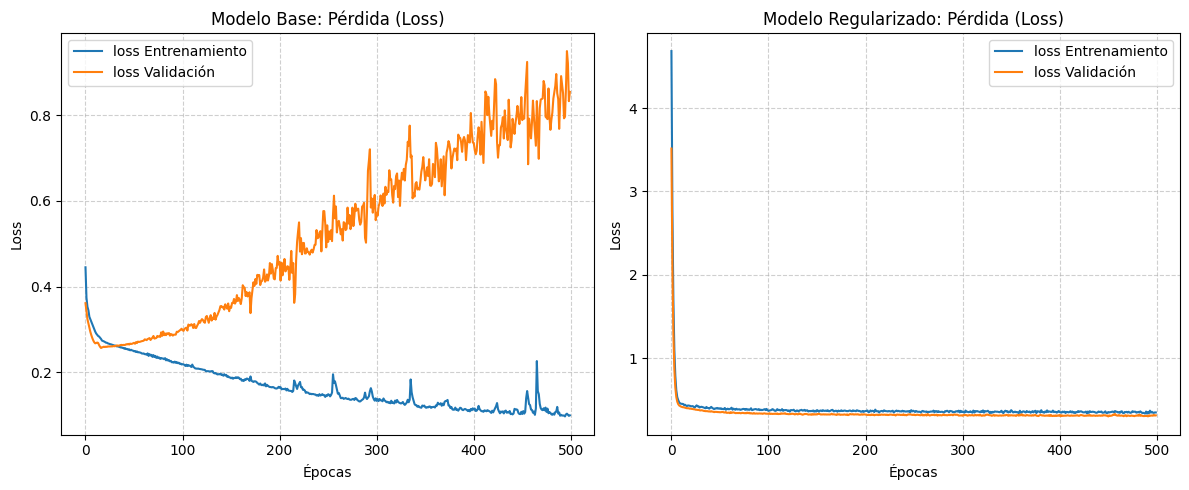

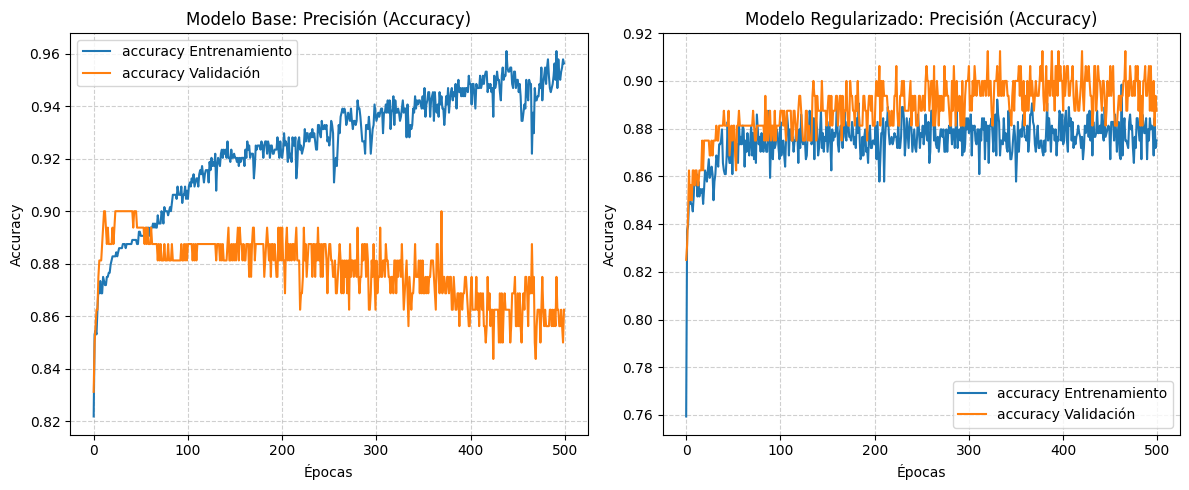

----------------------------------------
Resultados en el conjunto de Prueba (Test):
----------------------------------------
Modelo Base         -> Loss: 0.6564 | Accuracy: 0.8100
Modelo Regularizado -> Loss: 0.3184 | Accuracy: 0.8750
----------------------------------------


In [3]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Configurar semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Generar dataset
X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)

# Dividir en entrenamiento y validación
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de validación: {X_val.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

# Definición del modelo base
modelo_base = Sequential([
    Dense(256, activation='relu', input_shape=(2,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')]) # Salida binaria


modelo_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento por 500 épocas
print("Entrenando Modelo Base...")
historia_base = modelo_base.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    verbose=0) # Silenciado para no llenar la pantalla
print("Entrenamiento del Modelo Base finalizado.")

# Implementando técnica de regularización
factor_l2 = 0.01
tasa_dropout = 0.4

modelo_reg = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(factor_l2), input_shape=(2,)),
    Dropout(tasa_dropout),
    Dense(256, activation='relu', kernel_regularizer=l2(factor_l2)),
    Dropout(tasa_dropout),
    Dense(256, activation='relu', kernel_regularizer=l2(factor_l2)),
    Dropout(tasa_dropout),
    Dense(1, activation='sigmoid')])

modelo_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento por 500 épocas
print("Entrenando Modelo Regularizado...")
historia_reg = modelo_reg.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    verbose=0)
print("Entrenamiento del Modelo Regularizado finalizado.")

# Función para graficar la comparación
def graficar_comparacion(hist1, hist2, metrica, titulo):
    plt.figure(figsize=(12, 5))

    # Modelo Base
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history[metrica], label=f'{metrica} Entrenamiento')
    plt.plot(hist1.history[f'val_{metrica}'], label=f'{metrica} Validación')
    plt.title(f'Modelo Base: {titulo}')
    plt.xlabel('Épocas')
    plt.ylabel(metrica.capitalize())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Modelo Regularizado
    plt.subplot(1, 2, 2)
    plt.plot(hist2.history[metrica], label=f'{metrica} Entrenamiento')
    plt.plot(hist2.history[f'val_{metrica}'], label=f'{metrica} Validación')
    plt.title(f'Modelo Regularizado: {titulo}')
    plt.xlabel('Épocas')
    plt.ylabel(metrica.capitalize())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Graficar Loss
graficar_comparacion(historia_base, historia_reg, 'loss', 'Pérdida (Loss)')

# Graficar Accuracy
graficar_comparacion(historia_base, historia_reg, 'accuracy', 'Precisión (Accuracy)')

# Evaluación en el set de Test
loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
loss_reg, acc_reg = modelo_reg.evaluate(X_test, y_test, verbose=0)

print("-" * 40)
print(f"Resultados en el conjunto de Prueba (Test):")
print("-" * 40)
print(f"Modelo Base         -> Loss: {loss_base:.4f} | Accuracy: {acc_base:.4f}")
print(f"Modelo Regularizado -> Loss: {loss_reg:.4f} | Accuracy: {acc_reg:.4f}")
print("-" * 40)
